In [1]:
import tensorflow as tf

2026-02-03 12:11:19.117721: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 12:11:19.147532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 12:11:19.962934: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28)


In [3]:
# Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

/media/ahsan/drive1/Projects/tensorflow_course/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1770102698.309497 1405118 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3771 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [5]:
# Train the model
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

Epoch 1/10


2026-02-03 12:11:59.610821: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e87d401c3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-03 12:11:59.610834: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-02-03 12:11:59.622047: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-03 12:11:59.672507: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 190/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - accuracy: 0.6345 - loss: 1.1979

I0000 00:00:1770102720.306903 1405859 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9114 - loss: 0.3017 - val_accuracy: 0.9587 - val_loss: 0.1400
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 908us/step - accuracy: 0.9574 - loss: 0.1441 - val_accuracy: 0.9709 - val_loss: 0.0969
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step - accuracy: 0.9683 - loss: 0.1062 - val_accuracy: 0.9756 - val_loss: 0.0819
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - accuracy: 0.9743 - loss: 0.0861 - val_accuracy: 0.9777 - val_loss: 0.0729
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 956us/step - accuracy: 0.9768 - loss: 0.0741 - val_accuracy: 0.9777 - val_loss: 0.0743
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.9789 - loss: 0.0660 - val_accuracy: 0.9786 - val_loss: 0.0721
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 928us/step - accuracy: 0.9813 - loss: 0.0590 - val_accuracy: 0.9818 - val_loss: 0.0651
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 888us/step - accuracy: 0.9832 - loss: 0.0522

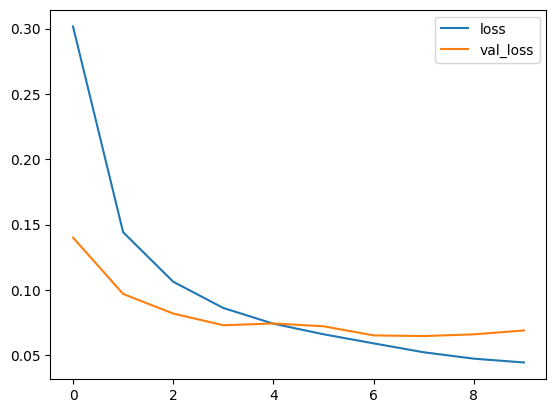

In [6]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

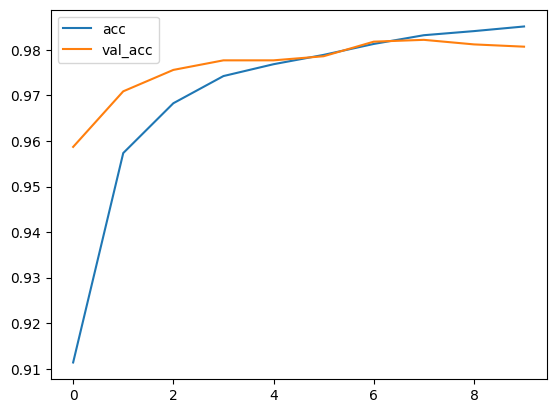

In [7]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [8]:
# Evaluate the model
print(model.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.9807 - loss: 0.0689
[0.06887394934892654, 0.9807000160217285]


In [9]:
# Convert the model to TFLite format

# Create a converter object
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Convert the model
tflite_model = converter.convert()

# Save to file
with open("converted_model.tflite", "wb") as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpq0xn71u_/assets


INFO:tensorflow:Assets written to: /tmp/tmpq0xn71u_/assets


Saved artifact at '/tmp/tmpq0xn71u_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139128165170832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128158194384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128158194960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128158192464: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1770102768.543895 1405118 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1770102768.543908 1405118 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-03 12:12:48.544134: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpq0xn71u_
2026-02-03 12:12:48.544433: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-03 12:12:48.544438: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpq0xn71u_
I0000 00:00:1770102768.546515 1405118 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-02-03 12:12:48.546882: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-03 12:12:48.582128: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpq0xn71u_
2026-02-03 12:12:48.586164: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 